Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
dtype: int64
Accuracy: 0.8246268656716418
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       157
           1       0.83      0.72      0.77       111

    accuracy                           0.82       268
   macro avg       0.83      0.81      0.82       268
weighted avg       0.83      0.82      0.82       268

Confusion matrix:
 [[141  16]
 [ 31  80]]


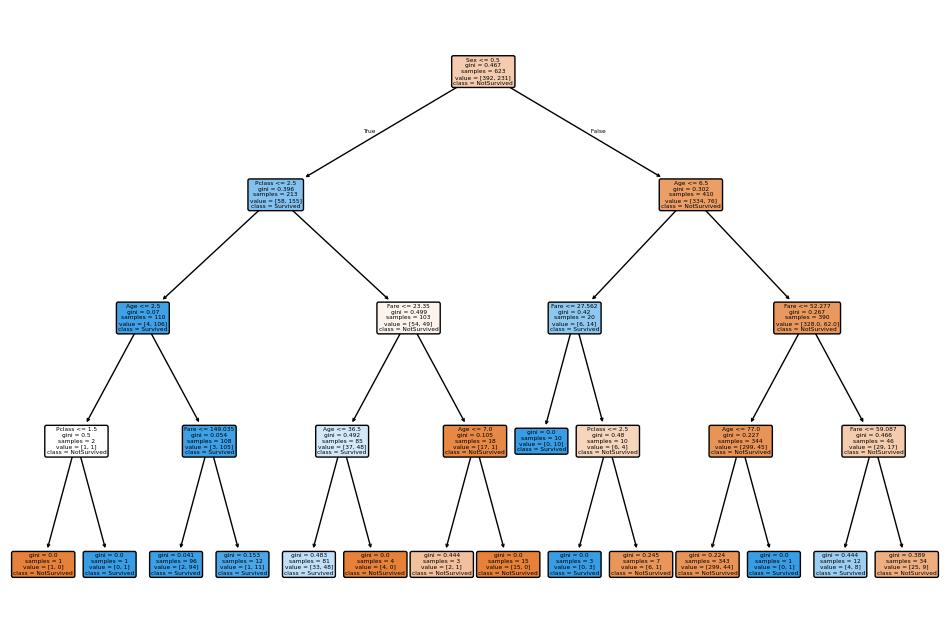

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

df=pd.read_csv('Titanic-Dataset.csv')
df=df[['Survived','Pclass','Sex','Age','Fare']]
df['Age']=df['Age'].fillna(df['Age'].median())
df['Sex']=df['Sex'].map({'male':1,'female':0})

print(df.isnull().sum())

X = df[['Pclass','Sex','Age','Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

tree=DecisionTreeClassifier(max_depth=4,random_state=42)
tree.fit(X_train,y_train)

Y_pred_tree=tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, Y_pred_tree))
print(classification_report(y_test, Y_pred_tree))
print("Confusion matrix:\n", confusion_matrix(y_test,Y_pred_tree))
plt.figure(figsize=(12,8))
plot_tree(tree, feature_names=X.columns, class_names=['NotSurvived','Survived'], filled=True, rounded=True)
plt.show()